In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/processed/cleaned_telco.csv')
df.shape

(7043, 21)

### Graphs of Important Features

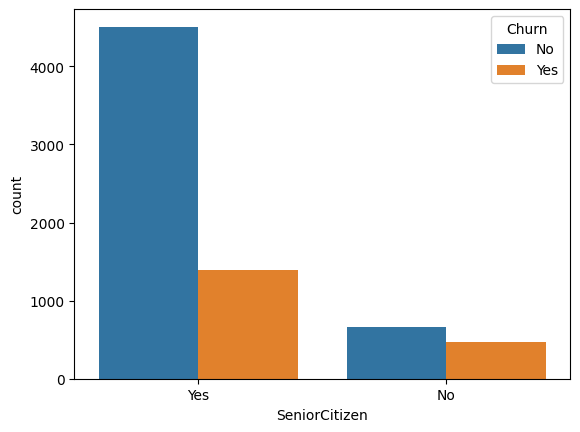

In [25]:
sns.countplot(x='SeniorCitizen', hue = 'Churn', data=df)
plt.show()

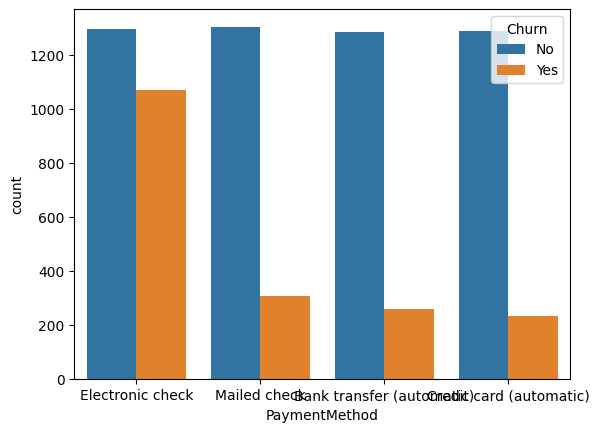

In [26]:
sns.countplot(x='PaymentMethod', hue = 'Churn', data=df)
plt.show()

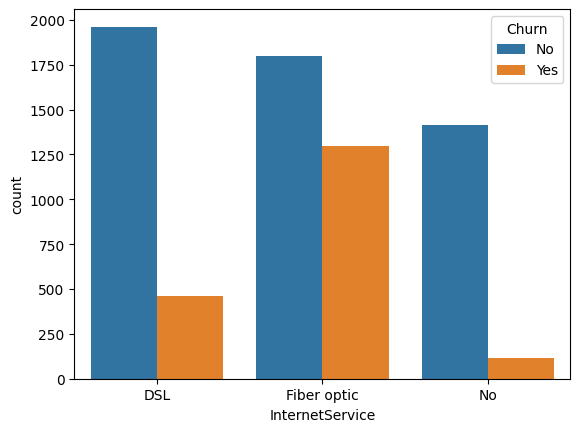

In [27]:
sns.countplot(x='InternetService', hue = 'Churn', data=df)
plt.show()

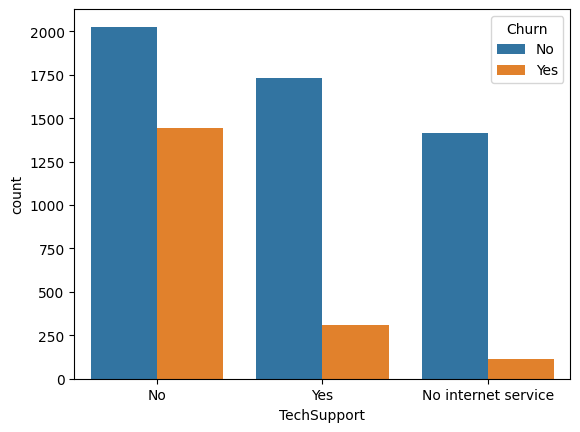

In [28]:
sns.countplot(x='TechSupport', hue = 'Churn', data=df)
plt.show()

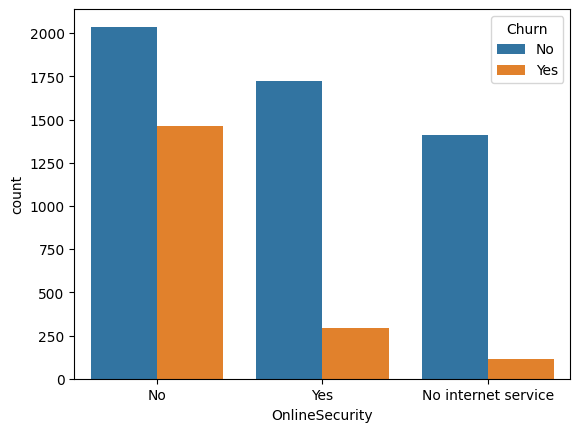

In [29]:
sns.countplot(x='OnlineSecurity', hue = 'Churn', data=df)
plt.show()

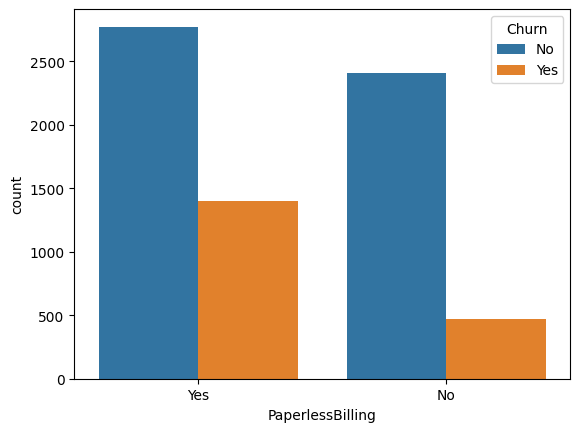

In [30]:
sns.countplot(x='PaperlessBilling', hue = 'Churn', data=df)
plt.show()

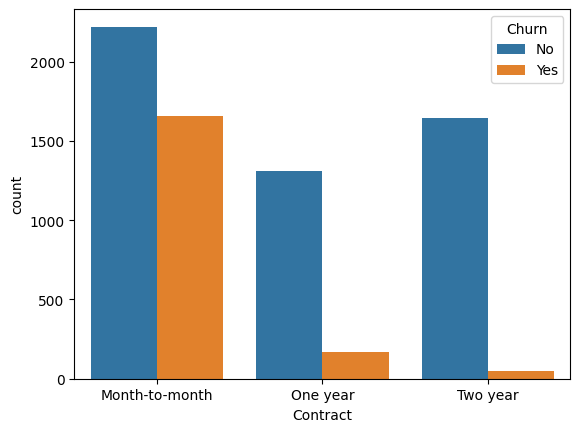

In [31]:
sns.countplot(x='Contract', hue = 'Churn', data=df)
plt.show()

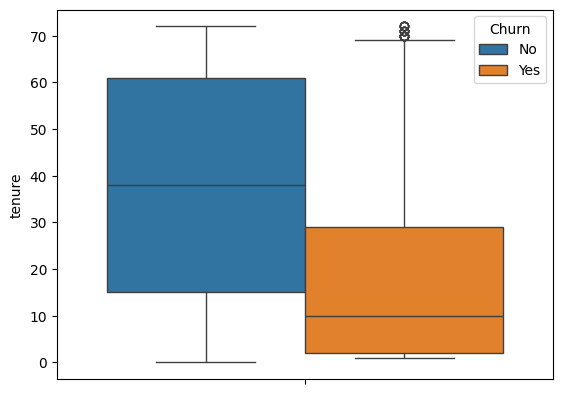

In [32]:
sns.boxplot(y='tenure', hue='Churn',data=df)
plt.show()

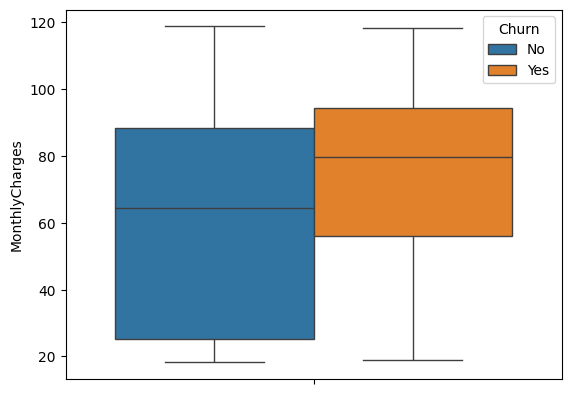

In [33]:
sns.boxplot(y='MonthlyCharges', hue='Churn',data=df)
plt.show()

### New dataframe with categorical values separate

In [34]:
df_imp = df[['PaymentMethod', 'InternetService', 'TechSupport', 'Contract', 'tenure', 'MonthlyCharges', 'Churn']]
df_encoded = pd.get_dummies(df_imp, drop_first=True)
df_encoded.columns

Index(['tenure', 'MonthlyCharges', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_One year', 'Contract_Two year', 'Churn_Yes'],
      dtype='object')

### Correlation matrix

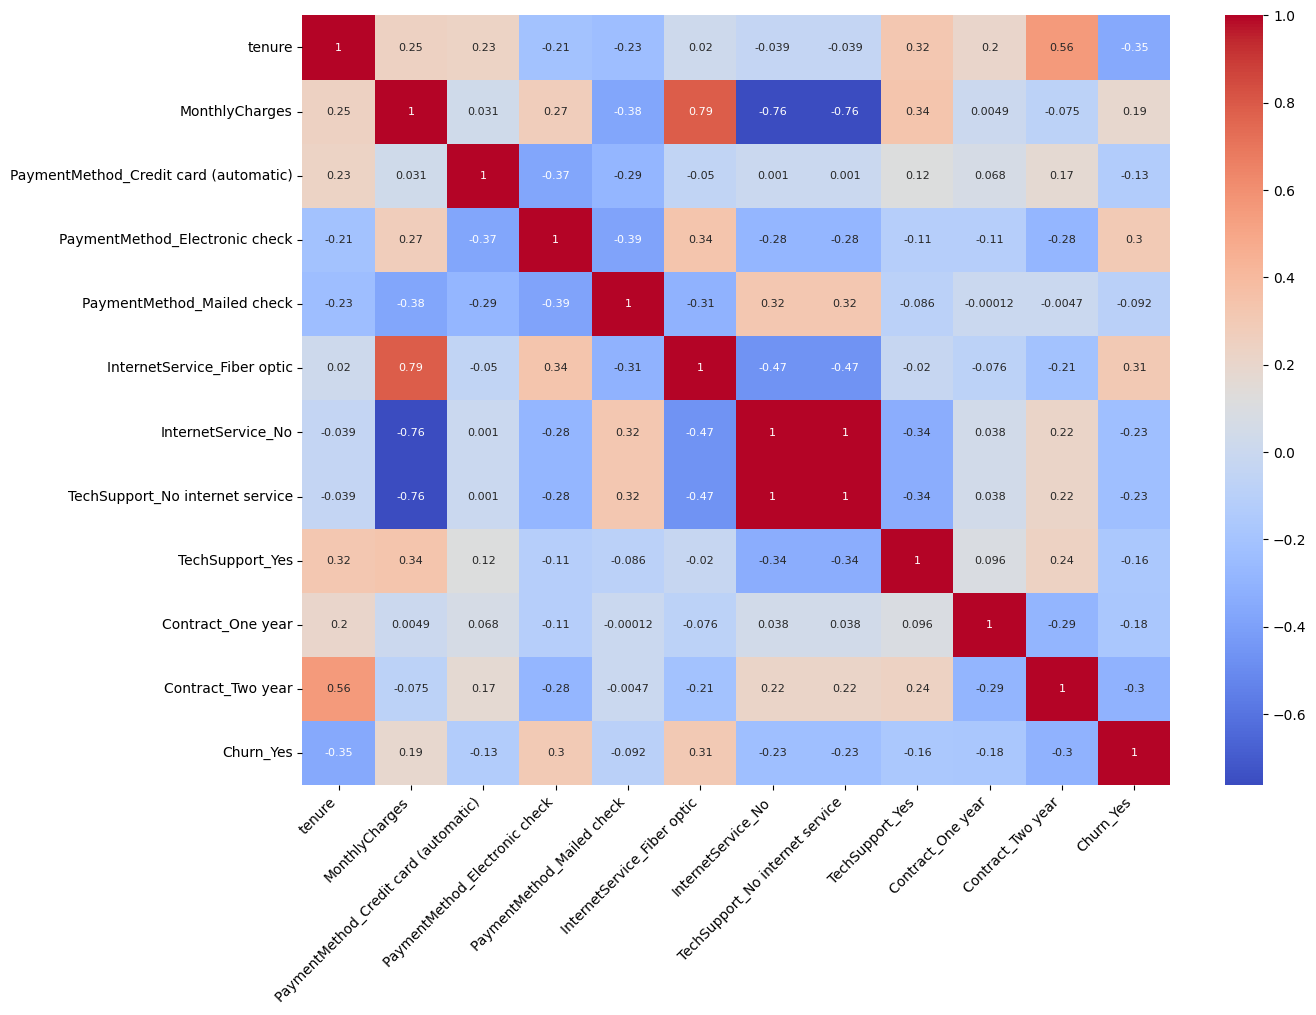

In [35]:
corr = df_encoded.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', annot_kws={"size":8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### Statistical Values of Features to Churn rate using groupby()

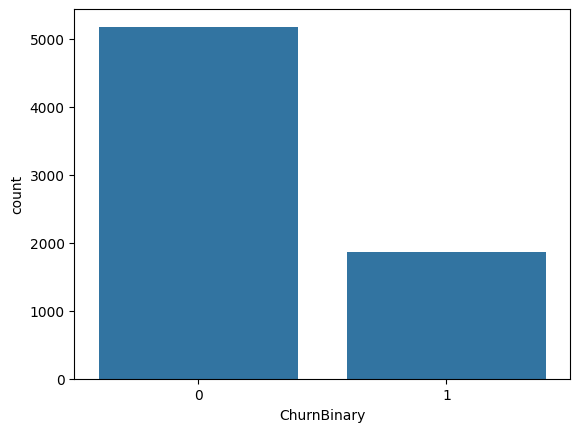

In [36]:
df['ChurnBinary'] = df['Churn'].map({'Yes':1, 'No':0})
sns.countplot(x='ChurnBinary', data=df)
plt.show()

In [37]:
df.groupby('PaymentMethod')['ChurnBinary'].mean()

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: ChurnBinary, dtype: float64

In [38]:
df.groupby('InternetService')['ChurnBinary'].mean()

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: ChurnBinary, dtype: float64

In [39]:
df.groupby('TechSupport')['ChurnBinary'].mean()

TechSupport
No                     0.416355
No internet service    0.074050
Yes                    0.151663
Name: ChurnBinary, dtype: float64

In [40]:
df.groupby('Contract')['ChurnBinary'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnBinary, dtype: float64

In [41]:
df.groupby('Churn')['tenure'].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

In [42]:
df.groupby('Churn')['MonthlyCharges'].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [43]:
df.groupby('Churn')[['tenure', 'MonthlyCharges']].median()

,tenure,MonthlyCharges
Churn,,
No,38.0,64.425
Yes,10.0,79.650


In [44]:
df.groupby('Contract')['ChurnBinary'].agg(['mean', 'count'])

,mean,count
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


## Key Findings

- Customers using **Electronic Check** as their payment method exhibit significantly higher churn rates (~45%) compared to customers using other payment methods (~15–20%).

- Customers with **Fiber Optic** internet service demonstrate higher churn behavior (~42%) compared to customers using DSL services (~18%).

- Customers without **Tech Support** services are substantially more likely to churn (~42%) than customers who have Tech Support (~15%).

- Customers on **Month-to-Month contracts** show the highest churn rates (~43%), whereas customers with long-term yearly contracts exhibit much lower churn behavior (~11%).

- Customers who churn generally have a **shorter tenure**, with a median tenure of approximately 10 months compared to 38 months for retained customers.

- Customers who churn tend to have **higher monthly charges**, with median monthly charges around 80 compared to 65 for customers who remain with the company.

- Overall, contract type, customer tenure, support services, and billing characteristics appear to play important roles in customer churn behavior.